# 04 — The first GNN: relation-aware GraphSAGE

This studybook completes the project's first end-to-end GNN comparison. It assumes the graph schema from notebook 00, the temporal evaluation contract from 01, the baselines from 02, the topology vocabulary from 03, and the GraphSAGE mechanism from `01_architectures/graphsage.ipynb`.

The question is deliberately narrow: **does two-hop, relation-aware message passing beat the strong LightGBM baseline on the same mature post-cutoff cohort?** The answer may be yes or no; changing the protocol after seeing test performance would make either answer untrustworthy.

## 1. What is being fitted?

The model uses two GraphSAGE layers with separate parameters for `sold_by`, `owed_by`, `sells`, and `owes`. Instrument and company features enter with different widths but become 64-dimensional hidden states. A linear classifier maps the final instrument state to one impairment logit.

```mermaid
flowchart LR
    X[cutoff-safe node features] --> L1[relation-aware GraphSAGE layer 1]
    L1 --> N[layer normalization + ReLU + dropout]
    N --> L2[company → instrument GraphSAGE layer 2]
    L2 --> Z[64-dimensional instrument embedding]
    Z --> C[linear classifier]
    C --> S[impairment score]
```

The second layer only computes destination instrument states because those are the prediction units. Omitting an unused second company update avoids parameters that could never receive a classifier gradient.

## 2. The test period remains untouched during model selection

The latest 20% of mature pre-cutoff instruments is a temporal validation block beginning 2017-12-05. A search model trains on earlier mature labels, and validation PR-AUC selects the epoch. A fresh seed-42 model then trains for exactly that many epochs on all mature pre-cutoff labels.

Training uses class-weighted binary cross-entropy because impairments are rare. Final CPU execution uses deterministic PyTorch algorithms. The inference graph blocks post-cutoff instruments from sending messages into companies, so test cases receive historical company context but cannot influence one another. Test labels are read only after fitting has finished.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from graph_ml.data import GraphBuildConfig, build_trade_finance_graph
from graph_ml.evaluation import TemporalSplitConfig, build_temporal_evaluation_split
from graph_ml.training import (
    GraphSAGETrainingConfig,
    evaluate_graphsage_run,
    fit_hetero_graphsage,
)
from graph_ml.viz import (
    embedding_projection_frame,
    plot_baseline_pr_auc,
    plot_embedding_projection,
    plot_score_distributions,
    plot_seed_variability,
    plot_training_history,
    seed_metric_summary,
)

repo_root = next(parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "pyproject.toml").exists())
data_path = repo_root / "data/02_instrumentsdf_2.parquet"
if not data_path.exists():
    raise FileNotFoundError("The real local Parquet data is required; see wiki/this-project/data-availability.md")

instruments = pd.read_parquet(data_path)
graph_result = build_trade_finance_graph(instruments, GraphBuildConfig(cutoff="2018-04-30"))
split = build_temporal_evaluation_split(
    instruments, graph_result, TemporalSplitConfig(analysis_date="2018-12-18")
)
config = GraphSAGETrainingConfig()
run = fit_hetero_graphsage(graph_result, split, config)
{
    "selected_epoch": run.best_epoch,
    "validation_pr_auc": run.best_validation_pr_auc,
    "epochs_searched": len(run.search_train_losses),
    "parameters": run.parameter_count,
    "device": "cpu",
    "seed": run.seed,
}

{'selected_epoch': 139,
 'validation_pr_auc': 0.26087355409043955,
 'epochs_searched': 169,
 'parameters': 22849,
 'device': 'cpu',
 'seed': 42}

## 3. Read the training history before the test result

Loss and validation PR-AUC answer different questions. The loss measures the weighted objective on fit labels; PR-AUC measures ranking on later pre-cutoff labels. The selected epoch is where validation PR-AUC last improves materially, not where fit loss is smallest.

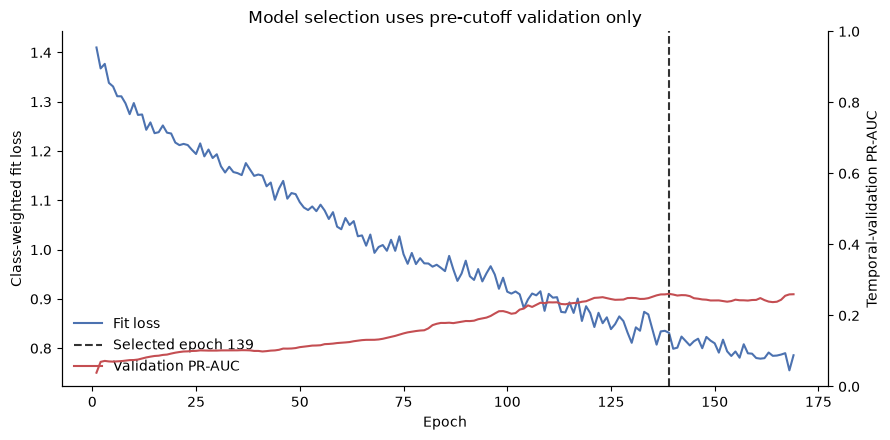

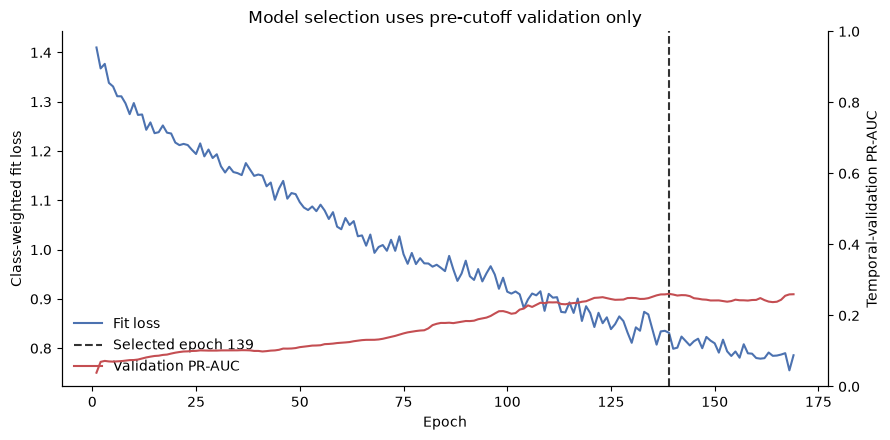

In [2]:
plot_training_history(
    run.search_train_losses,
    run.search_validation_pr_aucs,
    best_epoch=run.best_epoch,
)

Validation PR-AUC peaks at 0.261 at epoch 139. Training continues for 30 non-improving epochs because patience protects against stopping on one noisy fluctuation; the fresh final model still trains for only the selected 139 epochs.

## 4. Honest comparison with the fixed baselines

Every row below uses the same cutoff, maturity rule, cohort masks, and top-5% review budget. The black marker in the chart is cohort prevalence—the PR-AUC of a no-skill ranking. Comparing uplift within a cohort is safer than comparing raw PR-AUC across cohorts with different prevalence.

In [3]:
labels = graph_result.graph["instrument"].y.numpy()
gnn_report = evaluate_graphsage_run(run, labels, split, review_fraction=0.05)
baseline_report = pd.read_csv(repo_root / "results/baseline_metrics.csv")
comparison = pd.concat(
    [
        baseline_report.loc[baseline_report["model"].isin(["logistic_instrument", "lightgbm_instrument_company"])],
        gnn_report,
    ],
    ignore_index=True,
)
comparison[["model", "cohort", "prevalence", "pr_auc", "roc_auc", "precision_at_k", "recall_at_k"]].style.format(
    {"prevalence": "{:.2%}", "pr_auc": "{:.3f}", "roc_auc": "{:.3f}", "precision_at_k": "{:.2%}", "recall_at_k": "{:.2%}"}
)

,model,cohort,prevalence,pr_auc,roc_auc,precision_at_k,recall_at_k
0,logistic_instrument,test_all,5.62%,0.074,0.402,9.46%,8.43%
1,logistic_instrument,test_seen,4.12%,0.096,0.566,11.83%,14.38%
2,logistic_instrument,test_cold_start,10.42%,0.068,0.216,2.70%,1.30%
3,lightgbm_instrument_company,test_all,5.62%,0.465,0.913,49.03%,43.68%
4,lightgbm_instrument_company,test_seen,4.12%,0.432,0.900,34.65%,42.12%
5,lightgbm_instrument_company,test_cold_start,10.42%,0.387,0.904,28.83%,13.91%
6,hetero_graphsage,test_all,5.62%,0.305,0.818,42.37%,37.74%
7,hetero_graphsage,test_seen,4.12%,0.291,0.790,28.17%,34.25%
8,hetero_graphsage,test_cold_start,10.42%,0.319,0.884,21.62%,10.43%


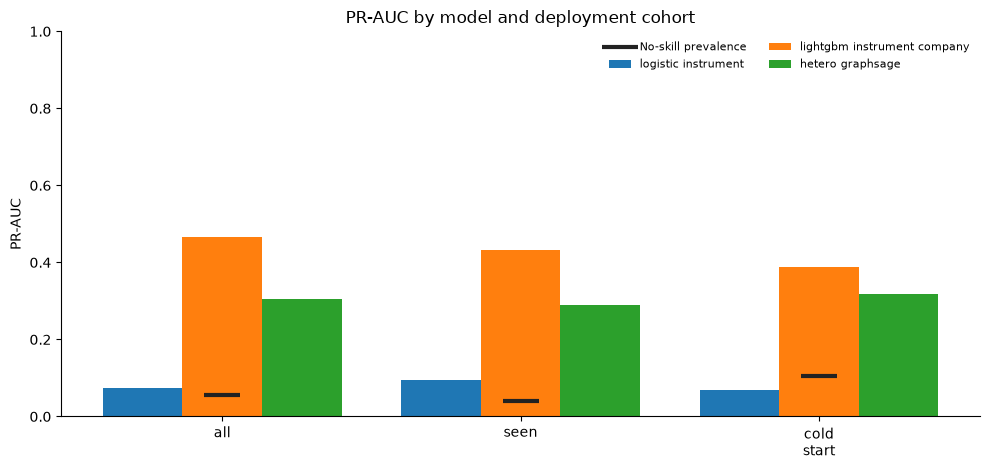

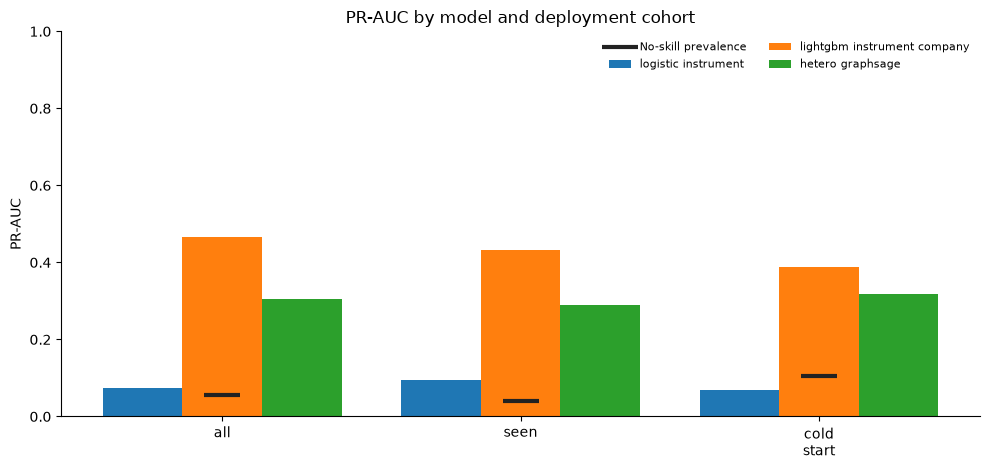

In [4]:
plot_baseline_pr_auc(comparison)

### Conclusion: useful signal, but LightGBM wins

The reported seed-42 GraphSAGE run reaches **0.305 overall PR-AUC**, well above logistic regression's 0.074 but below LightGBM's 0.465. The gap is 0.160 PR-AUC overall, 0.141 on seen-company cases, and 0.068 on cold-start cases. At the overall top-5% review budget, GraphSAGE precision is 42.37% and recall is 37.74%, versus 49.03% and 43.68% for LightGBM.

Cold-start GraphSAGE PR-AUC is 0.319, but prevalence is already 10.42%; its top-5% recall is only 10.43%. This is not a hidden win. The narrower cold-start gap does suggest inductive aggregation remains worth investigating, but the current model does not justify replacing the strong tree baseline.

## 5. One seed is not an uncertainty estimate

Neural-network initialization and dropout ordering can change the optimization path even when data and hyperparameters stay fixed. After freezing the configuration, four additional deterministic CPU runs were made with seeds 7, 19, 73, and 101. No hyperparameter was changed and test results did not select a preferred seed. The CSV stores all five runs; this notebook reruns seed 42 and reads the others to keep execution time reasonable.

In [5]:
seed_runs = pd.read_csv(repo_root / "results/gnn_metrics.csv")
robustness = seed_metric_summary(seed_runs)
robustness.style.format(
    {"mean": "{:.3f}", "sample_std": "{:.3f}", "minimum": "{:.3f}", "maximum": "{:.3f}"}
)

,cohort,run_count,mean,sample_std,minimum,maximum
0,test_all,5,0.244,0.079,0.115,0.305
1,test_seen,5,0.276,0.085,0.127,0.337
2,test_cold_start,5,0.202,0.087,0.083,0.319


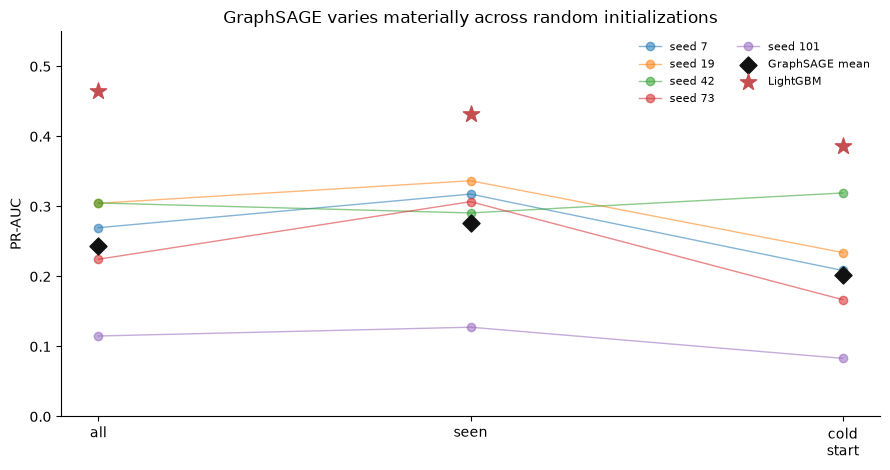

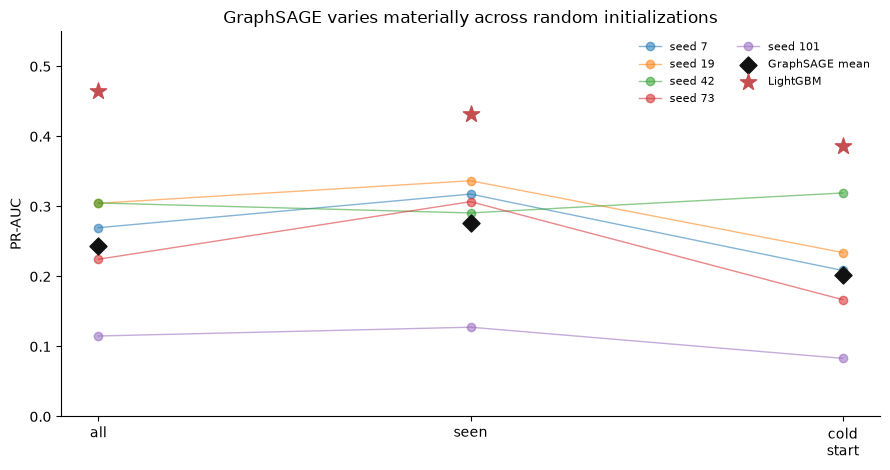

In [6]:
lightgbm_benchmark = (
    baseline_report.loc[baseline_report["model"] == "lightgbm_instrument_company"]
    .set_index("cohort")["pr_auc"]
    .to_dict()
)
plot_seed_variability(seed_runs, benchmark_pr_auc=lightgbm_benchmark)

The model is materially unstable: overall PR-AUC is **0.244 ± 0.079** (sample standard deviation), spanning 0.115–0.305. Seen-company PR-AUC averages 0.276 ± 0.085; cold-start averages 0.202 ± 0.087. Seed 42 is the joint maximum overall and on cold-start, so quoting only 0.305 would overstate typical performance. No seed beats LightGBM in any overall run.

This strengthens the negative conclusion: the current GraphSAGE is not merely below the baseline; its optimization is insufficiently reliable. The next model work should improve training stability and report multiple seeds as a default, while keeping architecture choices on pre-cutoff validation data.

## 6. What do the scores look like?

A ranking metric compresses two overlapping score distributions into one number. Density normalization gives each class equal visual area, preventing the many negatives from hiding the positive distribution. Good separation would place impaired instruments farther right with little overlap.

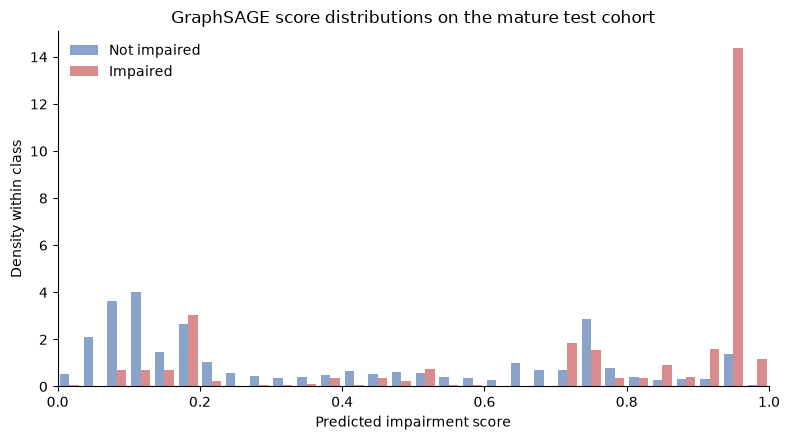

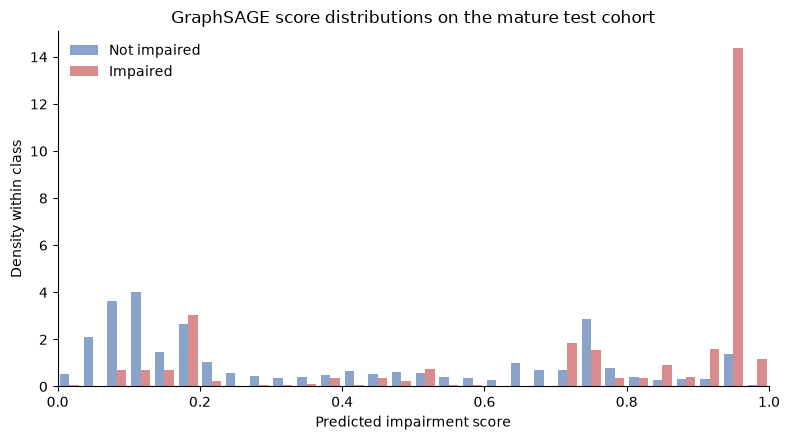

In [7]:
test_mask = split.test_mask.numpy()
plot_score_distributions(labels[test_mask], run.scores[test_mask])

Impaired cases shift toward higher scores, which explains the useful PR-AUC, but the distributions still overlap heavily. A threshold cannot cleanly separate the classes; operational review capacity therefore remains essential. These sigmoid scores are rankings, not yet calibrated probabilities.

## 7. Looking inside the learned representation

Each test instrument ends as a 64-dimensional embedding. PCA rotates those vectors onto the two directions with greatest variance. The plot keeps every positive in a deterministic sample and adds negatives up to 2,000 points. It is anonymous and descriptive: two visible axes cannot prove class separability or explain causality.

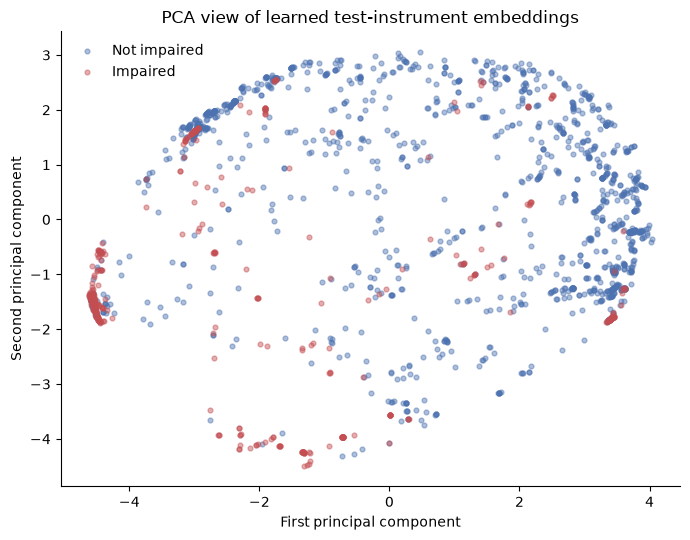

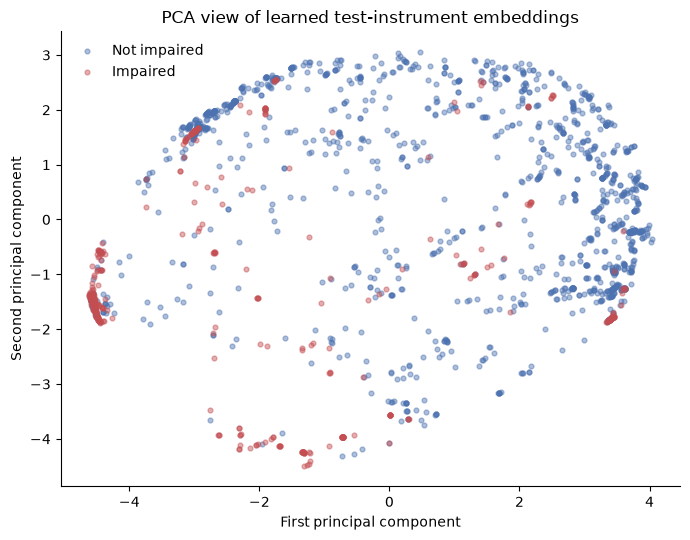

In [8]:
projection = embedding_projection_frame(
    run.instrument_embeddings[test_mask],
    labels[test_mask],
    max_points=2_000,
    seed=42,
)
plot_embedding_projection(projection)

## 8. Why might trees outperform this GNN?

Four explanations fit the evidence without inventing a failure story after the fact:

1. **Strong structured baseline:** LightGBM is exceptionally good at nonlinear thresholds and interactions among 32 engineered, cutoff-safe columns.
2. **Redundant local context:** company nodes already contain pre-cutoff counts and means. Two-hop mean aggregation may relearn a noisier version of information LightGBM receives directly.
3. **Hub dilution:** an unweighted mean treats every visible neighbouring instrument equally. Companies with thousands of invoices may average away rare local signals.
4. **Limited receptive field:** two layers reach same-company siblings, not the longer hybrid-mediated paths that motivate network contagion. Adding depth blindly risks over-smoothing and is not an honest automatic fix.

The next architecture work should test these hypotheses with validation-only choices: feature ablations, multiple seeds, relation attention or degree-aware aggregation, and eventually strictly temporal message passing. The held-out test remains a reporting set, not a hyperparameter oracle.

## 9. Verify the committed result artifact

The CSV records enough configuration and fit metadata to reproduce the headline run without committing model weights. The assertion protects the published numbers from drifting away from this executable notebook.

In [9]:
committed = pd.read_csv(repo_root / "results/gnn_metrics.csv")
metric_columns = ["prevalence", "pr_auc", "roc_auc", "precision_at_k", "recall_at_k"]
current = gnn_report.sort_values("cohort").reset_index(drop=True)
saved = committed.loc[committed["seed"] == run.seed].sort_values("cohort").reset_index(drop=True)
np.testing.assert_allclose(current[metric_columns], saved[metric_columns], rtol=0, atol=5e-9)
assert run.best_epoch == int(saved.loc[0, "best_epoch"])
assert run.parameter_count == int(saved.loc[0, "parameter_count"])
"Committed GraphSAGE result log matches this run."

'Committed GraphSAGE result log matches this run.'

## Takeaways

- The first relation-aware GraphSAGE completes the honest data→baseline→GNN vertical slice.
- Temporal validation selects 139 epochs without consulting post-cutoff labels.
- Seed 42 learns real ranking signal (0.305 PR-AUC) but does **not** beat LightGBM (0.465).
- Across five frozen-configuration seeds, overall PR-AUC is only 0.244 ± 0.079; seed 42 is the maximum, not the typical run.
- Cold-start remains operationally difficult and especially initialization-sensitive.
- Two-hop message passing tests learned same-company aggregation, not genuine multi-hop contagion.
- A negative benchmark result is useful: it narrows the next research questions without weakening the evaluation contract.